# pyXenium.io Tutorial

## Overview

This notebook uses the public 10x Genomics FFPE human renal carcinoma Xenium RNA + protein study to show how `pyXenium.io` preserves the structures that matter for downstream biology: cells, transcript points, aligned H&E, and cluster-aware metadata.

## Biological question

Before we ask multimodal or topology questions, how do we keep the Xenium export organized enough to recover tissue architecture, image context, and molecular measurements in one reproducible container?


In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate the pyXenium repository root.")


REPO_ROOT = find_repo_root()
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 12)


In [2]:
RENAL_DATASET_PATH = Path(
    os.environ.get(
        "PYXENIUM_RENAL_DATASET",
        r"Y:\long\10X_datasets\Xenium\Xenium_Renal\Xenium_V1_Human_Kidney_FFPE_Protein",
    )
)
SMOKE_ARTIFACT_DIR = REPO_ROOT / "manuscript" / "evidence" / "smoke_auto"
RUN_LIVE_IO_DEMO = RENAL_DATASET_PATH.exists()

RENAL_DATASET_PATH, SMOKE_ARTIFACT_DIR, RUN_LIVE_IO_DEMO


(WindowsPath('Y:/long/10X_datasets/Xenium/Xenium_Renal/Xenium_V1_Human_Kidney_FFPE_Protein'),
 WindowsPath('D:/GitHub/pyXenium/manuscript/evidence/smoke_auto'),
 True)

## Dataset

- Raw study: 10x Genomics Xenium FFPE human renal cell carcinoma RNA + protein bundle.
- Versioned evidence in this repository: `manuscript/evidence/smoke_auto/` and `manuscript/figures/figure1_pyxenium_validation.png`.
- Public surface used in this tutorial: `read_xenium`, `read_sdata`, `write_xenium`, and `export_xenium_to_spatialdata_zarr`.

## Setup

The committed outputs below come from a real renal dataset run. The live demo cell also loads the local Xenium bundle when `RENAL_DATASET_PATH` exists.


In [3]:
smoke_payload = json.loads((SMOKE_ARTIFACT_DIR / "summary.json").read_text(encoding="utf-8"))
summary = smoke_payload["summary"]

core_summary = pd.DataFrame(
    {
        "metric": [
            "cells",
            "RNA features",
            "protein markers",
            "sparse nnz",
            "spatial coordinates",
            "cluster labels",
        ],
        "value": [
            summary["n_cells"],
            summary["n_rna_features"],
            summary["n_protein_markers"],
            summary["x_nnz"],
            summary["has_spatial"],
            summary["has_cluster"],
        ],
    }
)

display(core_summary)
display(pd.DataFrame(summary["largest_clusters"]).head(5))
display(pd.DataFrame(summary["top_protein_markers_by_mean_signal"]).head(5))


,metric,value
0,cells,465545
1,RNA features,405
2,protein markers,27
3,sparse nnz,16454170
4,spatial coordinates,True
5,cluster labels,True


,cluster,n_cells
0,1,87757
1,2,67261
2,3,59896
3,4,53975
4,5,35331


,marker,mean_signal,positive_cells
0,Vimentin,234.769989,455851
1,CD45,206.936478,446921
2,PTEN,149.335358,464946
3,CD3E,142.478271,285619
4,CD68,120.736671,244801


## Core workflow

The canonical I/O path keeps Xenium data close to the original assay structure.

```python
from pyXenium.io import (
    export_xenium_to_spatialdata_zarr,
    read_sdata,
    read_xenium,
    write_xenium,
)

sdata = read_xenium(
    RENAL_DATASET_PATH,
    as_="sdata",
    prefer="h5",
    include_transcripts=True,
    stream_transcripts=True,
    include_images=True,
)

payload = write_xenium(sdata, "./renal_example.zarr", format="sdata", overwrite=True)
reloaded = read_sdata(payload["output_path"])
compat_store = export_xenium_to_spatialdata_zarr(RENAL_DATASET_PATH, overwrite=True)
```

For the committed notebook output we execute only the loading step, because the full round-trip writes a large real-data store.


In [4]:
from pyXenium.io import read_xenium

if RUN_LIVE_IO_DEMO:
    sdata = read_xenium(
        str(RENAL_DATASET_PATH),
        as_="sdata",
        prefer="h5",
        include_transcripts=True,
        stream_transcripts=True,
        include_boundaries=False,
        include_images=True,
    )
    live_summary = pd.DataFrame(
        {
            "component": [
                "table cells",
                "RNA features",
                "protein markers",
                "streamed point layers",
                "image layers",
                "cluster key",
            ],
            "value": [
                int(sdata.table.n_obs),
                int(sdata.table.n_vars),
                int(sdata.table.obsm["protein"].shape[1]),
                ", ".join(sdata.component_summary()["points"]),
                ", ".join(sdata.component_summary()["images"]),
                sdata.metadata.get("cluster_key"),
            ],
        }
    )
    display(live_summary)
else:
    display(Markdown("Set `PYXENIUM_RENAL_DATASET` to a local renal Xenium bundle to run the live loading demo."))


,component,value
0,table cells,465545
1,RNA features,405
2,protein markers,27
3,streamed point layers,transcripts
4,image layers,he
5,cluster key,gene_expression_graphclust


## Visual outputs

The validation figure below summarizes the same renal study at the documentation level: loader checks, feature recovery, and multimodal readiness.


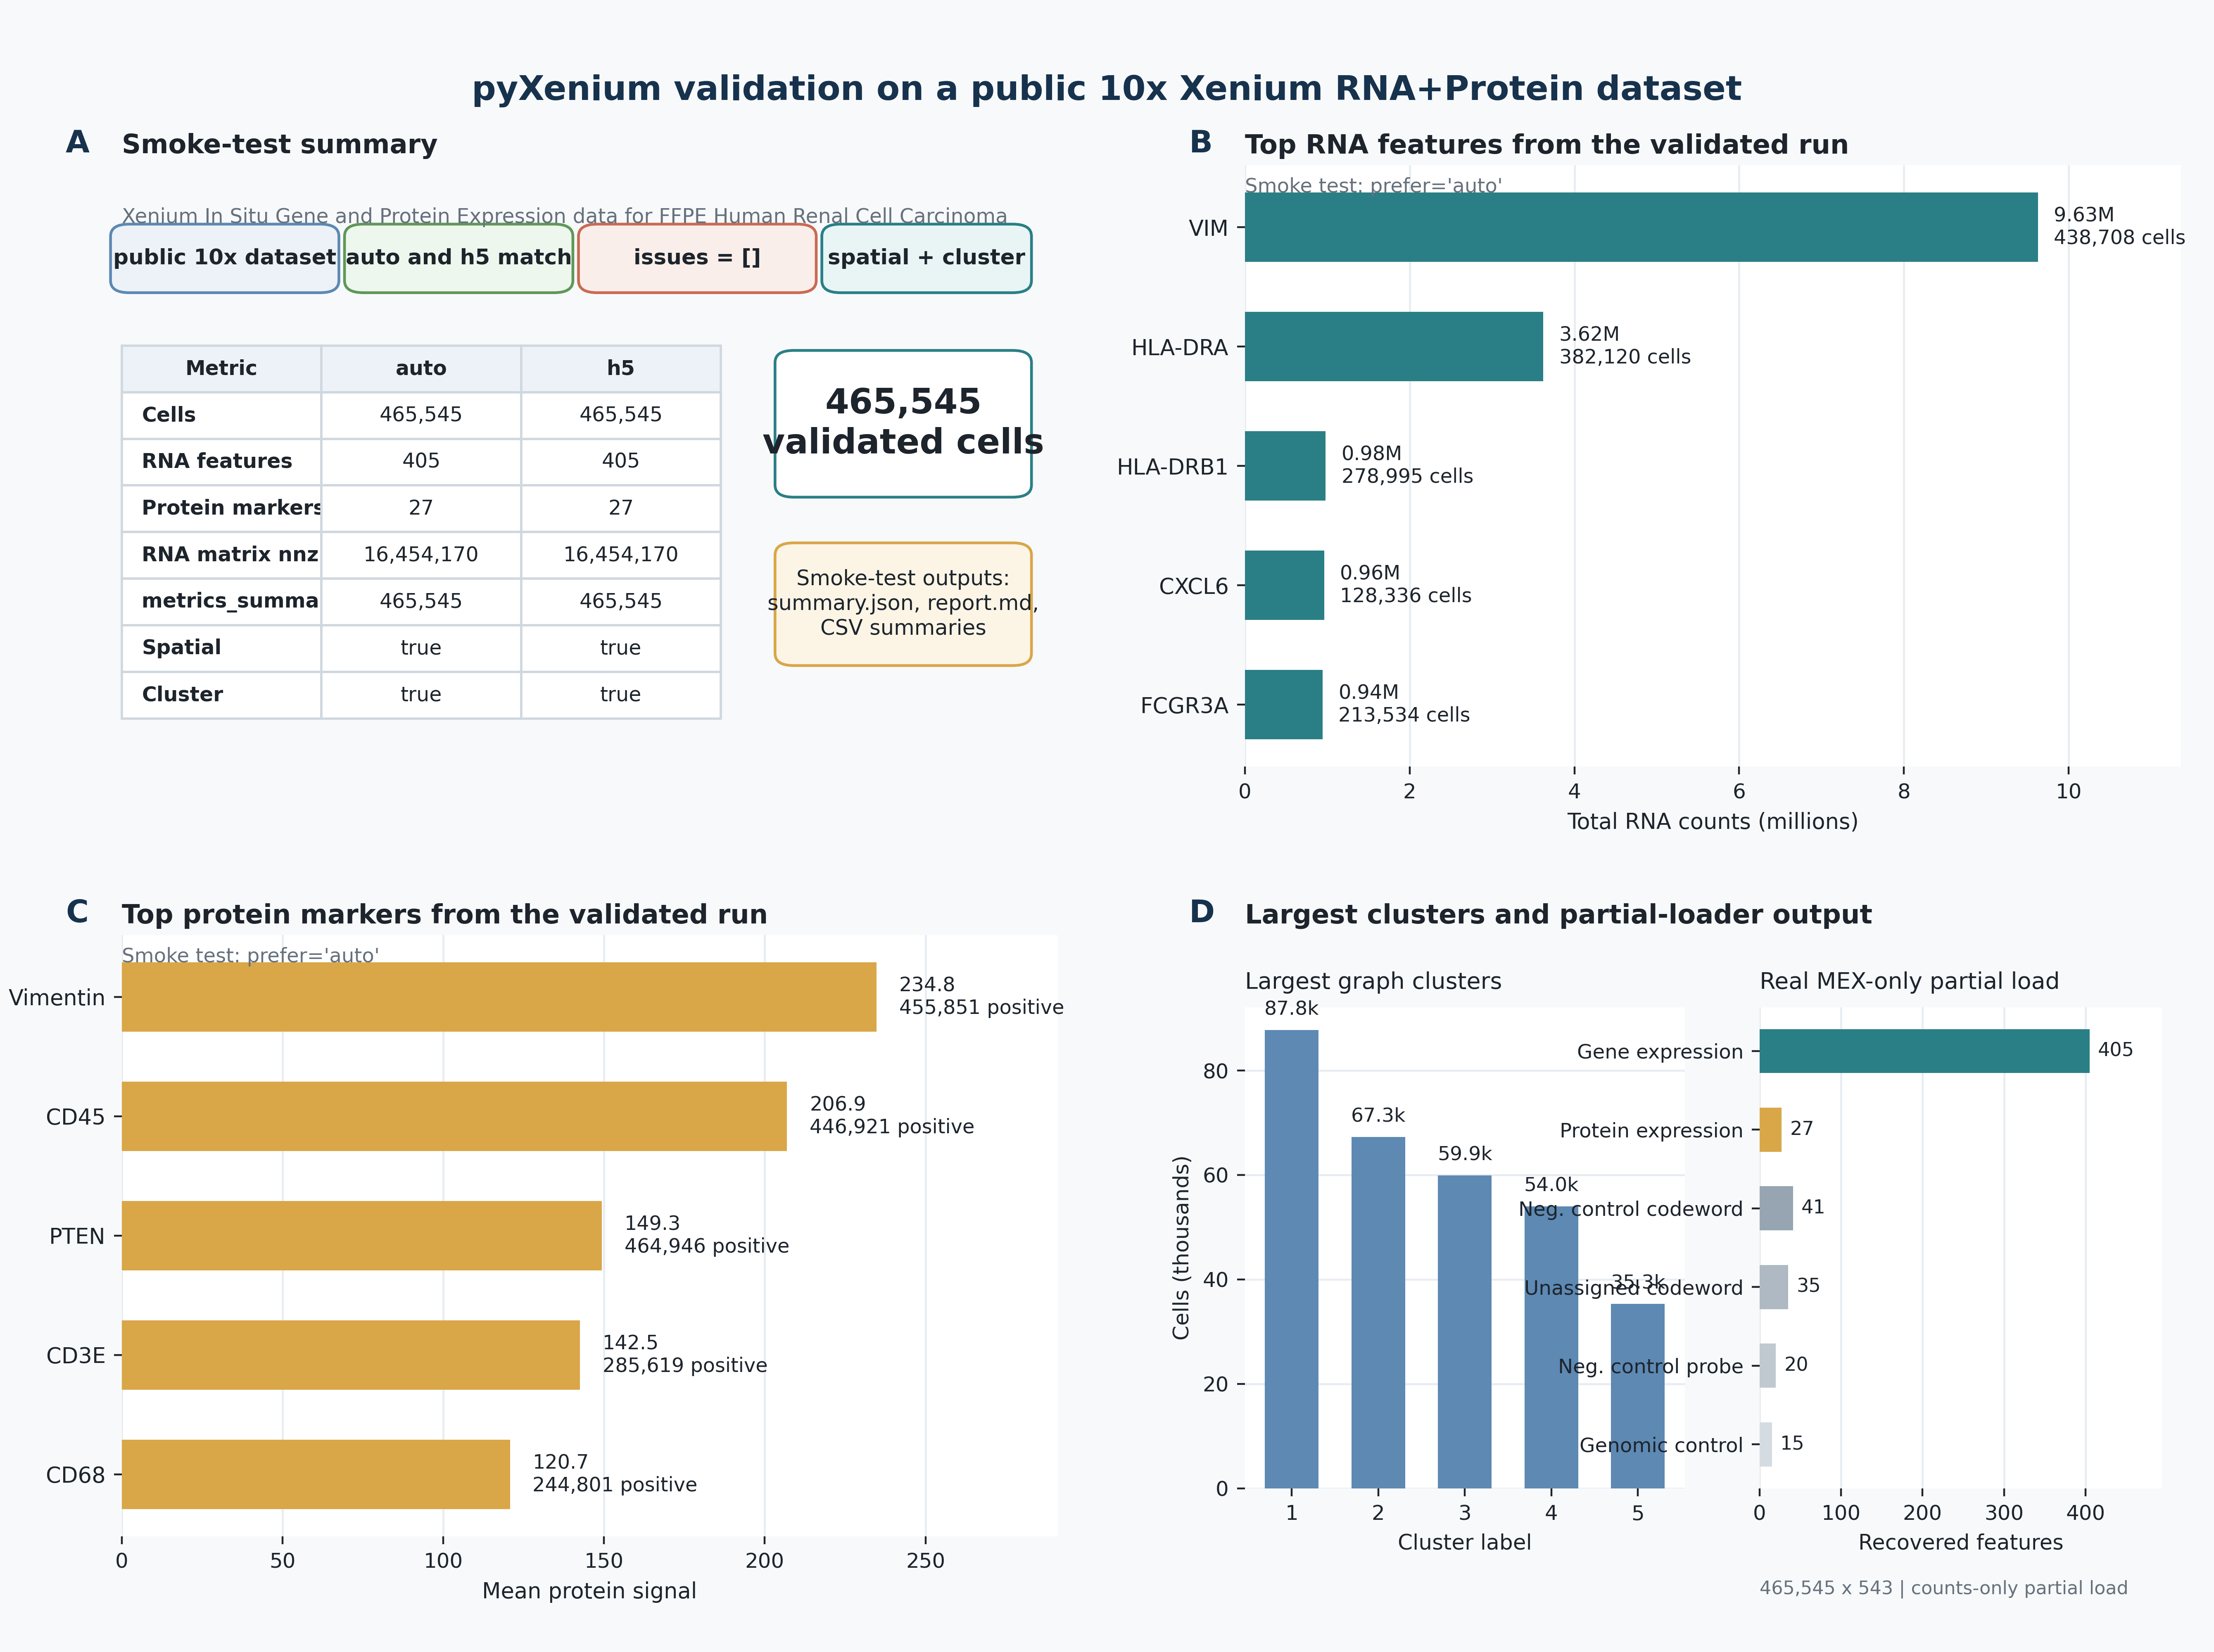

In [5]:
display(Image(filename=str(REPO_ROOT / "manuscript" / "figures" / "figure1_pyxenium_validation.png")))


## Biological interpretation

For renal immune-resistance work, I/O is not a neutral preprocessing step. It decides whether we can later connect protein-dominant states, transcript neighborhoods, and histology-aligned niches back to the same tissue coordinates. The validated renal bundle shows that pyXenium keeps enough structure to recover 465,545 cells, 405 RNA features, 27 protein markers, and aligned image context without collapsing those layers into a lossy flat table.

## Caveats

- The fully materialized round-trip examples are intentionally shown as code only because writing full real-data stores is much heavier than documentation rendering.
- This notebook streams transcript points instead of materializing them into memory; that is the preferred pattern for large Xenium exports.
- The public renal dataset is a validated reference, not a universal benchmark for every panel or tissue.

## Next steps

- Continue into the `multimodal` notebook to see how this same renal study becomes joint state, discordance, and niche analysis.
- Use `read_xenium(..., as_="sdata")` when you need images, shapes, or streamed transcripts together.
- Use `load_rna_protein_anndata(...)` when you are ready to work on joint RNA + protein analysis directly.
